# Wind Farm Layout Optimisation – Shell.ai Hackathon  
## Greedy Construction + Local Refinement

This notebook implements a solution using the **official AEP evaluator** (`Farm_Evaluator_Vec`) and the heuristic algorithms from your earlier scripts.  
We combine:

1. **Greedy placement** – sequentially add turbines on a coarse grid (e.g., 50 m spacing) to maximise AEP.
2. **Local refinement** – iteratively adjust each turbine within a small neighbourhood to further improve AEP.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
import os
import tempfile
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

from itertools import product
from tqdm import tqdm  # optional, for progress bars

from Farm_Evaluator_Vec import (
    getTurbLoc, loadPowerCurve, binWindResourceData,
    preProcessing, getAEP, checkConstraints
)

warnings.filterwarnings('ignore')

import os
print("My current folder:", os.getcwd())
print("Files in this folder:", os.listdir())

My current folder: C:\Users\ASUS\PracticeFiles\CornerStone
Files in this folder: ['.ipynb_checkpoints', 'Ar_512.py', 'Ar_512_without_feasible.py', 'CodeExperiments.ipynb', 'combined_wind_data_all_years.csv', 'Farm_Evaluator_Vec.py', 'Final_Approach.py', 'find_rest_point_in_small_space.py', 'find_rest_point_pein.py', 'PowerCurveData', 'power_curve.csv', 'turbine_layout.csv', 'turbine_loc_test.csv', 'turbine_optimal_layout.csv', 'two_turbine.py', 'Wind Farm Optimization Greedy.ipynb', 'Wind Farm Optimization-Copy1.ipynb', 'Wind Farm Optimization.ipynb', 'Wind Farm Optimization_Multy start Greedy.ipynb', 'Wind_Data', '__pycache__']


In [2]:
import sys
# Replace with the actual path to the folder containing your .py file
sys.path.append(r"C:\Users\ASUS\PracticeFiles\CornerStone") 

import Farm_Evaluator_Vec

In [3]:
# ---------- Data paths ----------
DATA_DIR = 'Wind_Data'

WIND_FILES = [
    os.path.join(DATA_DIR, 'wind_data_2007.csv'),
    os.path.join(DATA_DIR, 'wind_data_2008.csv'),
    os.path.join(DATA_DIR, 'wind_data_2009.csv'),
    os.path.join(DATA_DIR, 'wind_data_2013.csv'),
    os.path.join(DATA_DIR, 'wind_data_2014.csv'),
    os.path.join(DATA_DIR, 'wind_data_2015.csv'),
    os.path.join(DATA_DIR, 'wind_data_2017.csv')
]

# ---------- Combine DataFrames ----------
dataframes = []

for file in WIND_FILES:
    df = pd.read_csv(file)
    dataframes.append(df)

combined_wind_df = pd.concat(dataframes)

# Sort by date to keep the time-series chronological
combined_wind_df['date'] = pd.to_datetime(combined_wind_df['date'])
combined_wind_df.sort_values(by='date', ascending=True, inplace=True)

# Save the combined data to a physical file
# We use index=False so we don't accidentally create an extra column

combined_file_path = "combined_wind_data_all_years.csv"
combined_wind_df.to_csv(combined_file_path, index=False)
print(f"Successfully saved combined data to: {combined_file_path}")

Successfully saved combined data to: combined_wind_data_all_years.csv


In [4]:
combined_wind_df.head()

,date,drct,sped
0,2007-01-01 00:20:00,290.0,12.829798
1,2007-01-01 00:50:00,290.0,15.842659
2,2007-01-01 01:20:00,290.0,15.270610
3,2007-01-01 01:50:00,300.0,13.332094
4,2007-01-01 02:20:00,290.0,12.639211


In [5]:
combined_wind_df.tail()

,date,drct,sped
15902,2017-12-30 21:50:00,220.0,1.974951
15903,2017-12-30 22:20:00,180.0,2.330232
15904,2017-12-30 22:50:00,160.0,5.427657
15905,2017-12-30 23:20:00,170.0,6.016653
15906,2017-12-30 23:50:00,150.0,4.661694


In [6]:
combined_wind_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113113 entries, 0 to 15906
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    113113 non-null  datetime64[ns]
 1   drct    113113 non-null  float64       
 2   sped    113113 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 3.5 MB


In [7]:
power_curve_df = pd.read_csv('power_curve.csv')
power_curve_df.tail()

,Wind Speed (m/s),Thrust Coeffecient,Power (MW)
496,49.6,0.0,0.0
497,49.7,0.0,0.0
498,49.8,0.0,0.0
499,49.9,0.0,0.0
500,50.0,0.0,0.0


In [8]:
power_curve_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Wind Speed (m/s)    501 non-null    float64
 1   Thrust Coeffecient  501 non-null    float64
 2   Power (MW)          501 non-null    float64
dtypes: float64(3)
memory usage: 11.9 KB


In [9]:
power_curve_df['Thrust Coeffecient'].unique().sum()  #just to check if there exists Thrust coefficients with non zero values

np.float64(94.14530836399999)

### 2. Optimisation Algorithm

**2.1 Computation of  wind instance probabilities from the combined dataset:**

In [10]:
# CALLING THE OFFICIAL FUNCTION...

wind_inst_freq = binWindResourceData(combined_file_path)

print("Wind instance frequencies calculated successfully!")

Wind instance frequencies calculated successfully!


In [11]:
pd.DataFrame(wind_inst_freq).head()

,0
0,0.000955
1,0.003501
2,0.003775
3,0.003280
4,0.002272


**2.2 AEP evaluation wrapper:**

In [12]:
turb_rad = 50.0  # rotor radius in metres (diameter 100 m)
power_curve_arr = power_curve_df.to_numpy(dtype=np.float32)  # for fast lookups

def compute_aep(coords):
    """
    coords: list of (x, y) tuples or numpy array of shape (n,2)
    returns AEP in GWh.
    """
    if len(coords) == 0:
        return 0.0
    coords_arr = np.array(coords, dtype=np.float32)
    n_turbs = len(coords_arr)

    # Pre‑processing (vectorised) for the current number of turbines
    n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t = preProcessing(power_curve_arr, n_turbs)

    # Evaluate AEP
    aep = getAEP(turb_rad, coords_arr, power_curve_arr, wind_inst_freq,
                 n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t)
    return aep

**2.3 Greedy construction on a 400 m grid:**

In [13]:
# Candidate grid points (clearance 50 m from boundary, spacing 400 m)
x_vals = np.arange(50, 3950 + 1, 400)
y_vals = np.arange(50, 3950 + 1, 400)
candidates = list(product(x_vals, y_vals))

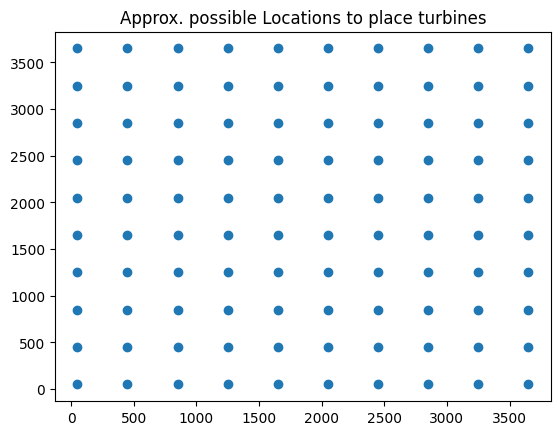

In [14]:
x_ax = np.array(candidates)[:,0]
y_ax =np.array(candidates)[:,1]

plt.scatter(x_ax, y_ax)
plt.title("Approx. possible Locations to place turbines")
plt.show()

In [16]:
greedy_selected = []
print("Greedy selection starting...")
start_time = time.time()

for i in range(50):
    best_aep = -1e9
    best_candidate = None
    # First turbine: any candidate gives the same AEP, so pick the first one
    if i == 0:
        best_candidate = candidates[0]
        # First turbine: any candidate gives the same AEP, so pick the first one

        best_aep = compute_aep([best_candidate])
        # Instantly calculate the true AEP for the first turbine so the print log is accurat
    else:
        # Evaluate all feasible candidates
        for cand in candidates:
            if cand in greedy_selected:
                continue
            # Proximity check
            distances = [np.linalg.norm(np.array(cand) - np.array(s)) for s in greedy_selected]
            if min(distances) < 400:
                continue
            temp_coords = greedy_selected + [cand] # list concatenation
            aep = compute_aep(temp_coords)
            if aep > best_aep:
                best_aep = aep
                best_candidate = cand
        if best_candidate is None:
            print("No feasible candidate found – this should not happen.")
            break
    greedy_selected.append(best_candidate)
    print(f"Placed turbine {i+1:2d}  |  AEP = {best_aep:.4f} GWh  |  time = {time.time()-start_time:.1f}s | Candidate = {best_candidate}")

print(f"\nGreedy finished after {time.time()-start_time:.1f} seconds.")
print(f"Final AEP after greedy: {compute_aep(greedy_selected):.4f} GWh")

Greedy selection starting...
Placed turbine  1  |  AEP = 11.2862 GWh  |  time = 0.0s | Candidate = (np.int64(50), np.int64(50))
Placed turbine  2  |  AEP = 22.5723 GWh  |  time = 0.4s | Candidate = (np.int64(450), np.int64(3650))
Placed turbine  3  |  AEP = 33.8585 GWh  |  time = 0.7s | Candidate = (np.int64(2050), np.int64(2050))
Placed turbine  4  |  AEP = 45.1447 GWh  |  time = 1.0s | Candidate = (np.int64(3250), np.int64(850))
Placed turbine  5  |  AEP = 56.3766 GWh  |  time = 1.3s | Candidate = (np.int64(3650), np.int64(3650))
Placed turbine  6  |  AEP = 67.4886 GWh  |  time = 1.7s | Candidate = (np.int64(2450), np.int64(3650))
Placed turbine  7  |  AEP = 78.5861 GWh  |  time = 2.0s | Candidate = (np.int64(2050), np.int64(50))
Placed turbine  8  |  AEP = 89.6617 GWh  |  time = 2.4s | Candidate = (np.int64(450), np.int64(1650))
Placed turbine  9  |  AEP = 100.6916 GWh  |  time = 2.7s | Candidate = (np.int64(3650), np.int64(2450))
Placed turbine 10  |  AEP = 111.6810 GWh  |  time = 

In [17]:
greedily_selected_coordinates = np.array(greedy_selected,dtype=np.float32)
greedily_selected_coordinates

array([[  50.,   50.],
       [ 450., 3650.],
       [2050., 2050.],
       [3250.,  850.],
       [3650., 3650.],
       [2450., 3650.],
       [2050.,   50.],
       [ 450., 1650.],
       [3650., 2450.],
       [3650.,   50.],
       [1650., 3650.],
       [1250.,   50.],
       [ 450., 2850.],
       [2850.,   50.],
       [3650., 1650.],
       [  50.,  850.],
       [  50., 2050.],
       [2450., 1250.],
       [ 850.,  850.],
       [2050., 2850.],
       [  50., 3650.],
       [3250., 3650.],
       [1250., 1650.],
       [ 850., 3650.],
       [1650.,  850.],
       [2850., 2850.],
       [ 450.,   50.],
       [3650.,  850.],
       [3650., 2850.],
       [1250., 2850.],
       [  50., 2850.],
       [2450.,  450.],
       [2450., 2050.],
       [  50., 1250.],
       [3250.,   50.],
       [3250., 2050.],
       [ 850., 2450.],
       [ 850.,   50.],
       [2850., 3650.],
       [1650., 2450.],
       [1650.,   50.],
       [2050., 3650.],
       [3650., 3250.],
       [125

**2.4 Local refinement (Hill climbing algorithm)**

In [24]:
def refine(selected, max_passes=10, step=50, range_=200):
    """
    For each turbine, try moving it within a square of side 2*range_ (step size `step`)
    while keeping constraints. Repeat for max_passes.
    """
    selected = list(selected)
    improved = True
    for _ in range(max_passes):
        if not improved:
            break
        improved = False
        for idx in range(len(selected)):
            best_aep = compute_aep(selected)
            best_coord = selected[idx]
            x0, y0 = selected[idx]
            # Candidate moves: all integer multiples of step within [-range_, range_]
            moves = [d for d in range(-range_, range_+1, step)]
            for dx in moves:
                for dy in moves:
                    if dx == 0 and dy == 0:
                        continue
                    nx = x0 + dx
                    ny = y0 + dy
                    # Boundary check (clearance 50 m)
                    if nx < 50 or nx > 3950 or ny < 50 or ny > 3950:
                        continue
                    # Check distance to other turbines
                    other_coords = selected[:idx] + selected[idx+1:]
                    if any(np.linalg.norm(np.array([nx, ny]) - np.array(s)) < 400 for s in other_coords):
                        continue
                    new_coords = other_coords + [(nx, ny)]
                    new_aep = compute_aep(new_coords)
                    if new_aep > best_aep:
                        best_aep = new_aep
                        best_coord = (nx, ny)
                        improved = True
            if best_coord != selected[idx]:
                selected[idx] = best_coord
                print(f"Moved turbine {idx+1} to {best_coord} -> AEP = {best_aep:.4f} GWh")
    return selected

print("\nStarting local refinement...")
refined = refine(greedy_selected, max_passes=3, step=50, range_=200)
final_aep = compute_aep(refined)
print(f"\nRefinement finished. Final AEP = {final_aep:.4f} GWh")


Starting local refinement...
Moved turbine 2 to (np.int64(400), np.int64(3850)) -> AEP = 506.4737 GWh
Moved turbine 3 to (np.int64(1850), np.int64(1850)) -> AEP = 506.8773 GWh
Moved turbine 4 to (np.int64(3100), np.int64(1050)) -> AEP = 507.4526 GWh
Moved turbine 5 to (np.int64(3850), np.int64(3850)) -> AEP = 508.5678 GWh
Moved turbine 6 to (np.int64(2450), np.int64(3750)) -> AEP = 508.8017 GWh
Moved turbine 7 to (np.int64(2100), np.int64(50)) -> AEP = 509.3051 GWh
Moved turbine 8 to (np.int64(600), np.int64(1850)) -> AEP = 509.6572 GWh
Moved turbine 9 to (np.int64(3750), np.int64(2350)) -> AEP = 510.2542 GWh
Moved turbine 10 to (np.int64(3800), np.int64(50)) -> AEP = 510.8248 GWh
Moved turbine 11 to (np.int64(1650), np.int64(3600)) -> AEP = 511.0151 GWh
Moved turbine 12 to (np.int64(1250), np.int64(100)) -> AEP = 511.1945 GWh
Moved turbine 13 to (np.int64(500), np.int64(2850)) -> AEP = 511.9012 GWh
Moved turbine 14 to (np.int64(2700), np.int64(50)) -> AEP = 512.3871 GWh
Moved turbine

In [25]:
final_coordinates = np.array(refined, dtype=np.float32)
final_coordinates

array([[  50.,   50.],
       [ 350., 3900.],
       [1800., 1800.],
       [3100., 1050.],
       [3850., 3850.],
       [2550., 3750.],
       [2100.,   50.],
       [ 600., 1850.],
       [3850., 2300.],
       [3950.,   50.],
       [1650., 3600.],
       [1250.,  100.],
       [ 400., 2750.],
       [2850.,   50.],
       [3850., 1850.],
       [ 100.,  900.],
       [  50., 1950.],
       [2700., 1150.],
       [ 850.,  750.],
       [2150., 3000.],
       [  50., 3550.],
       [3400., 3850.],
       [1450., 1500.],
       [ 800., 3650.],
       [1550.,  650.],
       [3050., 3150.],
       [ 450.,  100.],
       [3600.,  850.],
       [3850., 2850.],
       [1150., 3050.],
       [  50., 3050.],
       [2400.,  600.],
       [2250., 2200.],
       [  50., 1350.],
       [3500.,   50.],
       [3300., 2200.],
       [1050., 2250.],
       [ 850.,   50.],
       [2950., 3850.],
       [1700., 2600.],
       [1650.,   50.],
       [2050., 3650.],
       [3850., 3300.],
       [125

**2.5 Save final layout**

In [26]:
df_out = pd.DataFrame(final_coordinates, columns=['x', 'y'])
df_out.to_csv('turbine_optimal_layout.csv', index=False)
print("\nFinal turbine coordinates saved to 'turbine_optimal_layout.csv'.")


Final turbine coordinates saved to 'turbine_optimal_layout.csv'.


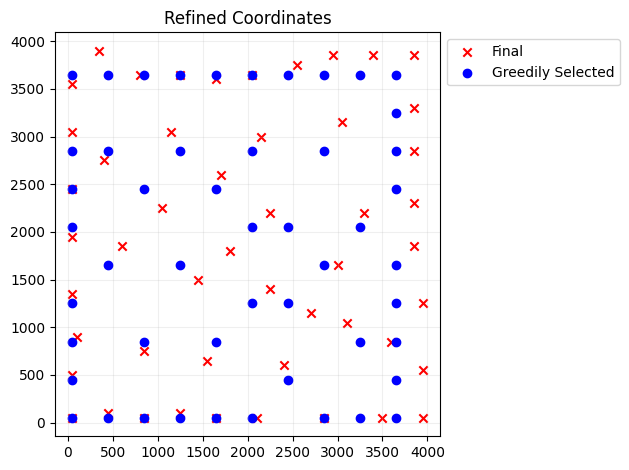

final AEP = 522.5858764648438 Ghw


In [27]:
import matplotlib.pyplot as plt

x = final_coordinates[:, 0]
y = final_coordinates[:, 1]
x2 = greedily_selected_coordinates[:, 0]
y2 = greedily_selected_coordinates[:, 1]

plt.scatter(x, y, color='red', marker='x', label='Final')
plt.scatter(x2, y2, color='blue', marker='o', label='Greedily Selected')

plt.title("Refined Coordinates") 

plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(alpha = 0.2)
plt.tight_layout()

plt.show()


print(f'final AEP = {final_aep} Ghw')